In [ ]:
#Consulta em Duas Etapas (Retrieve & Re-rank):

import psycopg2
import numpy as np
import pandas as pd
import requests
from scipy.spatial.distance import cosine # Importando a distância de cosseno
from sentence_transformers import SentenceTransformer
import json
import tkinter as tk
from tkinter import messagebox
import time
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.decomposition import PCA
import matplotlib.patches as patches
import traceback
import re
from sentence_transformers import CrossEncoder
from rank_bm25 import BM25Okapi
import nltk
nltk.download('punkt')
from nltk.tokenize import word_tokenize
# Listas globais para armazenar os rankings de todas as chamadas
lista_ids_ordem_cosseno = []
lista_ids_reordenados_int = []

# --- CONFIGURAÇÕES ---
# Inicializar modelo para gerar o embedding da consulta
print("Carregando o modelo de embeddings...")
modelo = SentenceTransformer('intfloat/multilingual-e5-small')
print("Modelo carregado.")

# Configurações da API Gemini
API_KEY = "Chave API"
API_URL = 'https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent'

# Configurações do Banco de Dados
DB_HOST = "localhost"
DB_NAME = "postgres" # Nome do banco de dados
DB_USER = "postgres"
DB_PORT = 5432
DB_PASS = "senha" 
DB_TABLE = "texto_avaliacao_ebserh" # Nome da tabela com os dados

# --- FUNÇÕES DE BANCO DE DADOS E LÓGICA DE RAG ---

def buscar_todos_os_dados():
    """Busca todos os dados necessários (id, texto_artigo, vector, texto_pagina) do banco."""
    try:
        conexao = psycopg2.connect(host=DB_HOST, port=DB_PORT, database=DB_NAME, user=DB_USER, password=DB_PASS)
        cursor = conexao.cursor()
        
        # Seleciona todas as colunas que serão usadas no processo
        cursor.execute(f"SELECT id, texto_artigo, vector, texto_pagina, nome_arquivo FROM {DB_TABLE}")
        
        resultados = cursor.fetchall()
        cursor.close()
        conexao.close()
        print(f"Encontrados {len(resultados)} registros no banco de dados.")
        return resultados
    except Exception as e:
        print(f"Erro ao conectar ou buscar dados do banco: {e}")
        return []

def recuperacao_inicial_por_similaridade(query_embedding, dados_banco, k=100):
    """
    Calcula a similaridade de cossenos e retorna os k chunks mais próximos.
    A distância de cosseno é 1 - similaridade de cosseno. Menor distância = maior similaridade.
    """
    # Calcula a distância de cosseno entre a query e todos os embeddings do banco
    # A estrutura de 'dado' agora é (id, texto_artigo, vector, texto_pagina)
    resultados_com_distancia = [
        (dado, cosine(query_embedding, np.array(json.loads(dado[2])).flatten()))
        for dado in dados_banco
    ]
    
    # Ordena pela distância (menor para o maior) e pega os top k
    resultados_ordenados = sorted(resultados_com_distancia, key=lambda x: x[1])[:k]
    
    # Retorna apenas os dados dos chunks, sem a distância
    top_k_chunks = [dado for dado, dist in resultados_ordenados]
    print(f"Recuperação inicial concluída. {len(top_k_chunks)} chunks selecionados.")
    return top_k_chunks
    #print(f"Recuperação inicial concluída. {len(resultados_ordenados)} chunks selecionados a partir de registros válidos.")
    #return resultados_ordenados # Retorna a lista de tuplas (dado, distancia)

def imprimir_rankings_para_comparacao(top_100_chunks, top_100_rrf):
    global lista_ids_ordem_cosseno, lista_ids_reordenados_int

    # 1. Extrai a lista de IDs da busca por cosseno (são inteiros)
    ids_ordem_cosseno = [chunk[0] for chunk in top_100_chunks]
    ids_ordem_rrf = [chunk[0] for chunk in top_100_rrf]
    # 2. Converte os IDs do Gemini (que são strings) para inteiros para uma comparação justa
   # ids_reordenados_int = []
   # for id_str in ids_reordenados:
       # try:
          #  ids_reordenados_int.append(int(id_str))
        #except (ValueError, TypeError):
           # print(f"Aviso: ID '{id_str}' retornado pelo Gemini não é um inteiro e será ignorado.")

    # 3. Armazena os rankings gerados nesta chamada
    lista_ids_ordem_cosseno.append(ids_ordem_cosseno)
    lista_ids_reordenados_int.append(ids_ordem_rrf)

def bm25_rank(top_chunks, query):
    """
    Recebe os 100 chunks recuperados por similaridade de cosseno e realiza reranqueamento com BM25.
    Retorna os mesmos chunks ordenados pela relevância BM25.
    """
    # Extrair os textos dos chunks (ajuste o índice conforme necessário)
    textos = [chunk[1] for chunk in top_chunks]  # Exemplo: chunk[1] é o 'texto_artigo'

    # Tokenização
    corpus_tokenizado = [word_tokenize(doc.lower()) for doc in textos]
    query_tokenizada = word_tokenize(query.lower())

    # Inicializa o modelo BM25
    bm25 = BM25Okapi(corpus_tokenizado)

    # Calcula os scores
    scores = bm25.get_scores(query_tokenizada)

    # Associa cada chunk ao seu score
    chunks_com_score = list(zip(top_chunks, scores))

    # Ordena pelo score decrescente
    rerankeado = sorted(chunks_com_score, key=lambda x: x[1], reverse=True)

    # Retorna só os chunks reranqueados
    return [chunk for chunk, score in rerankeado]

# ======= RRF =======

def rrf_rank(ranking1, ranking2, k=60):
    """
    Aplica Reciprocal Rank Fusion (RRF) nos rankings de chunks.
    Recebe dois rankings (listas de chunks) e retorna uma lista de chunks reranqueada.
    """
    from collections import defaultdict

    # Mapeia IDs para os próprios chunks
    id_para_chunk = {chunk[0]: chunk for chunk in ranking1 + ranking2}

    # Inicializa os scores RRF
    scores_rrf = defaultdict(float)

    # Ranking 1: Similaridade de Cosseno
    for rank, chunk in enumerate(ranking1):
        chunk_id = chunk[0]
        scores_rrf[chunk_id] += 1 / (k + rank)

    # Ranking 2: BM25
    for rank, chunk in enumerate(ranking2):
        chunk_id = chunk[0]
        scores_rrf[chunk_id] += 1 / (k + rank)

    # Ordena os chunks por score RRF
    ids_ordenados = sorted(scores_rrf.items(), key=lambda x: x[1], reverse=True)

    # Retorna a lista de chunks reranqueada
    return [id_para_chunk[chunk_id] for chunk_id, _ in ids_ordenados]


def rag_incremental(query, top_chunks, step=5, max_k=50):
    print("\n🚀 Iniciando RAG Incremental...")

    k = step
    total_tokens = 0
    num_chamadas = 0

    while k <= max_k:
        print(f"\n🔎 Testando com top-{k} chunks")

        subset = top_chunks[:k]

        contexto = [
            {"texto": chunk[3], "fonte": chunk[4]}
            for chunk in subset
        ]

        # Monta prompt (para contar tokens)
        contexto_str = " ".join([c["texto"] for c in contexto])
        prompt_estimado = f"{query} {contexto_str}"

        tokens_prompt = estimar_tokens(prompt_estimado)

        # chamada principal
        resposta = gerar_resposta_incremental_gemini(query, contexto)
        num_chamadas += 1

        tokens_resposta = estimar_tokens(resposta)
        total_tokens += tokens_prompt + tokens_resposta

        print("Resposta:", resposta)

        if "NÃO ENCONTRADO" in resposta:
            k += step
            continue

        # 🔍 verificação
        prompt_verificacao = f"{query} {resposta} {contexto_str}"
        tokens_verificacao_prompt = estimar_tokens(prompt_verificacao)

        valido = verificar_resposta_gemini(query, resposta, contexto)
        num_chamadas += 1

        tokens_verificacao_resposta = estimar_tokens(str(valido))
        total_tokens += tokens_verificacao_prompt + tokens_verificacao_resposta

        print("✔ Validação:", valido)

        if valido:
            print(f"✅ Resposta encontrada com top-{k}")
            return {
                "resposta": resposta,
                "k_utilizado": k,
                "status": "SUCESSO",
                "num_chamadas": num_chamadas,
                "tokens_estimados": total_tokens
            }
        else:
            print("❌ Falso positivo, continuando...")
            k += step

    return {
        "resposta": "NÃO ENCONTRADO",
        "k_utilizado": max_k,
        "status": "FALHA",
        "num_chamadas": num_chamadas,
        "tokens_estimados": total_tokens
    }

def orquestrar_rag_duas_etapas(query):
    dados_banco = buscar_todos_os_dados()
    if not dados_banco:
        return {
            "resposta": "Erro ao recuperar dados",
            "k_utilizado": 0,
            "num_chamadas": 0,
            "tokens_estimados": 0,
            "status": "ERRO"
        }

    # 🔹 Embedding da query
    embedding_query = modelo.encode(query).tolist()

    # 🔹 Recuperação inicial
    top_100_chunks = recuperacao_inicial_por_similaridade(
        embedding_query, dados_banco, k=100
    )

    # 🔹 BM25
    top_100_bm25 = bm25_rank(top_100_chunks, query)

    # 🔹 RRF
    top_100_rrf_chunks = rrf_rank(top_100_chunks, top_100_bm25, k=60)

    time.sleep(4)

    if not top_100_rrf_chunks:
        return {
            "resposta": "Erro no reranqueamento",
            "k_utilizado": 0,
            "num_chamadas": 0,
            "tokens_estimados": 0,
            "status": "ERRO"
        }

    print(f"🔎 Total de chunks disponíveis: {len(top_100_rrf_chunks)}")

    # 🔹 Estimativa custo Top-50 (baseline)
    tokens_top50 = estimar_tokens_topk(query, top_100_rrf_chunks, k=50)

    # 🚀 🔥 NOVA PARTE: RAG INCREMENTAL
    resultado_incremental = rag_incremental(
        query,
        top_100_rrf_chunks,
        step=5,     # tamanho do bloco
        max_k=50    # limite máximo
    )

    resultado_incremental["tokens_top50"] = tokens_top50

    # economia percentual
    if tokens_top50 > 0:
        resultado_incremental["economia_tokens"] = 1 - (
            resultado_incremental["tokens_estimados"] / tokens_top50
        )
    else:
        resultado_incremental["economia_tokens"] = 0

    return resultado_incremental
# --- BLOCO DE 
  
def gerar_resposta_incremental_gemini(query, chunks):
    contexto = ""
    for i, chunk in enumerate(chunks):
        contexto += f"Documento {i+1}:\n{chunk['texto']}\n\n"

        prompt = f"""
Você é um especialista em análise de documentos.

Sua tarefa é responder à pergunta com base nos textos fornecidos.

⚠️ REGRAS IMPORTANTES:
- Gere UMA ÚNICA resposta final
- NÃO responda por documento
- NÃO escreva "Documento 1", "Documento 2", etc.
- NÃO liste múltiplas respostas separadas
- NÃO repita trechos
- Seja objetiva e direta

- Se a resposta NÃO estiver presente nos textos, responda exatamente:
NÃO ENCONTRADO
    Pergunta:
    {query}

    Documentos:
    {contexto}
    """

    payload = {
        "contents": [{"parts": [{"text": prompt}]}]
    }

    try:
        response = requests.post(f"{API_URL}?key={API_KEY}",
                                 headers={'Content-Type': 'application/json'},
                                 json=payload)

        data = response.json()
        resposta = data['candidates'][0]['content']['parts'][0]['text'].strip()

        return resposta

    except Exception as e:
        print("Erro incremental:", e)
        return "ERRO"

def verificar_resposta_gemini(query, resposta, chunks):
    contexto = ""
    for i, chunk in enumerate(chunks):
        contexto += f"Documento {i+1}:\n{chunk['texto']}\n\n"

    prompt = f"""
    A resposta abaixo está REALMENTE suportada pelos documentos?

    Responda apenas com:
    SIM ou NÃO

    Pergunta:
    {query}

    Resposta:
    {resposta}

    Documentos:
    {contexto}
    """

    payload = {
        "contents": [{"parts": [{"text": prompt}]}]
    }

    try:
        response = requests.post(f"{API_URL}?key={API_KEY}",
                                 headers={'Content-Type': 'application/json'},
                                 json=payload)

        data = response.json()
        validacao = data['candidates'][0]['content']['parts'][0]['text'].strip().upper()

        return "SIM" in validacao

    except Exception as e:
        print("Erro verificação:", e)
        return False

def estimar_tokens(texto):
    if not texto:
        return 0
    return int(len(texto) / 4)

def estimar_tokens_topk(query, top_chunks, k=50):
    subset = top_chunks[:k]

    contexto = " ".join([chunk[3] for chunk in subset])

    prompt = f"""
    Responda à pergunta com base nos documentos abaixo.

    Pergunta:
    {query}

    Documentos:
    {contexto}
    """

    tokens_prompt = estimar_tokens(prompt)

    # Estimativa de resposta média (ajuste se quiser)
    tokens_resposta = 200  

    return tokens_prompt + tokens_resposta

def buscar_perguntas(limit=193):
    try:
        # --------------------------------------------------
        # 1) Leitura do CSV
        # --------------------------------------------------
        df = pd.read_csv(
            "perguntas_respostas_unificadas.xls",
            encoding="utf-8"
        )

        # --------------------------------------------------
        # 2) Seleciona as primeiras perguntas (ordem do CSV)
        # --------------------------------------------------
        perguntas = df["pergunta"].head(limit).tolist()

        return perguntas

    except Exception as e:
        print("❌ Erro ao buscar perguntas do arquivo CSV:")
        traceback.print_exc()
        return []

     
# --- BLOCO DE EXECUÇÃO PRINCIPAL ---
if __name__ == "__main__":
    perguntas = buscar_perguntas(limit=193)
    list_respostas = []
    
    for i, pergunta in enumerate(perguntas, 1):
        print(f"\n🔍 Processando pergunta {i}: \"{pergunta}\"\n")

        try:
            resultado = orquestrar_rag_duas_etapas(pergunta)


            list_respostas.append({
                "pergunta": pergunta,
                "resposta": resultado.get("resposta", ""),
                "k_utilizado": resultado.get("k_utilizado", 0),
                "num_chamadas": resultado.get("num_chamadas", 0),
                "tokens_incremental": resultado.get("tokens_estimados", 0),
                "tokens_top50": resultado.get("tokens_top50", 0),
                "economia_tokens": resultado.get("economia_tokens", 0),
                "status": resultado.get("status", "")
            })
           

            print("\n" + "="*100 + f" RESPOSTA {i} " + "="*100)
            print("Resposta:", resultado.get("resposta", ""))
            print("k_utilizado:", resultado.get("k_utilizado", 0))
            print("num_chamadas:", resultado.get("num_chamadas", 0))
            print("tokens_estimados:", resultado.get("tokens_estimados", 0))
            print("status:", resultado.get("status", ""))
            print("="*192)

            print(f"""
            📊 Comparação de custo:
            - Tokens incremental: {resultado.get("tokens_estimados", 0)}
            - Tokens Top-50: {resultado.get("tokens_top50", 0)}
            - Economia: {resultado.get("economia_tokens", 0)*100:.2f}%
            """)
                     
            
        except Exception as e:
            print(f"\n--- ERRO ao processar pergunta {i} ---")
            traceback.print_exc()
    # Criação dos DataFrames
    df_respostas = pd.DataFrame(list_respostas)
   
    # Salva resultados em arquivos CSV
    df_respostas.to_csv('resultados_incremental_gemini_2_5.csv')
    
   # print("\n📋 DataFrame - Cosine")
   # print(df_cosine.head())

    print("\n📋 DataFrame - Respostas")
    print(df_respostas.head())
    print("\n✅ Todas as perguntas foram processadas.")
    
    

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\mvcun\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Carregando o modelo de embeddings...
Modelo carregado.

🔍 Processando pergunta 1: "Quais formulários são mencionados no documento como disponíveis no site do HE -> Sistemas -> ADS Hospitalar -> Documentos -> USOST – Unidade de Saúde Ocupacional e Segurança do Trabalho, e para quais finalidades são utilizados?"

Encontrados 740 registros no banco de dados.
Recuperação inicial concluída. 100 chunks selecionados.
🔎 Total de chunks disponíveis: 100

🚀 Iniciando RAG Incremental...

🔎 Testando com top-5 chunks
Resposta: Os formulários mencionados no documento como disponíveis no site do HE -> Sistemas -> ADS Hospitalar -> Documentos -> USOST – Unidade de Saúde Ocupacional e Segurança do Trabalho, e suas finalidades, são:

*   **Formulário USOST-029 - Autorização para trabalho a quente:** Utilizado para atividades que envolvam fontes de ignição, como aquecimento, centelha ou chama, em áreas onde exista ou possa existir presença de material inflamável ou combustível com possibilidade de incênd

In [9]:
# Avaliação respostas geradas como re-ranker do RRF e Gemini2.5 flash
import pandas as pd
from bert_score import score

# --- BLOCO DE EXECUÇÃO PRINCIPAL ---
if __name__ == "__main__":
    
    # --------------------------------------------------------------
    # 1) Carrega as respostas de referência (gabarito) do CSV
    # --------------------------------------------------------------
    df_gabarito = pd.read_csv("perguntas_respostas_unificadas.xls")

    # Converte tudo para string e remove NaN
    df_gabarito["resposta"] = df_gabarito["resposta"].fillna("").astype(str)

    respostas_referencia = df_gabarito["resposta"].tolist()
    

    # --------------------------------------------------------------
    # 2) Carrega as respostas geradas pelo re-ranker
    # --------------------------------------------------------------
    df_respostas_rff = pd.read_csv(
        "resultados_incremental_gemini_2_5.csv"
    )

    # Converte para string
    df_respostas_rff["resposta"] = df_respostas_rff["resposta"].fillna("").astype(str)


    # Verificação de segurança
    if len(df_respostas_rff) != len(respostas_referencia):
        print(f"⚠️ Aviso: número de respostas não bate! {len(df_respostas_rff)} vs {len(respostas_referencia)}")
    
    # Ajustar tamanho mínimo comum
    n = min(len(df_respostas_rff), len(respostas_referencia))

    respostas_geradas = df_respostas_rff["resposta"].iloc[:n].tolist()
    referencias = respostas_referencia[:n]


    # --------------------------------------------------------------
    # 3) Calcula BERTScore
    # --------------------------------------------------------------
    print("Calculando BERTScore...")
    P, R, F1 = score(respostas_geradas, referencias, lang="pt", verbose=True)


    # --------------------------------------------------------------
    # 4) Monta DataFrame com resultados
    # --------------------------------------------------------------
    df_resultados = pd.DataFrame({
        "resposta_gerada": respostas_geradas,
        "resposta_referencia": referencias,
        "precision": P.tolist(),
        "recall": R.tolist(),
        "f1": F1.tolist()
    })


    # --------------------------------------------------------------
    # 5) Salva em CSV
    # --------------------------------------------------------------
    df_resultados.to_csv('resultados_bertscore_incremental_Gemini_2_5.csv', index=False)

    print("✅ Arquivo 'resultados_bertscore_incremental_Gemini_2_5.csv' salvo com sucesso.")
    print(f"\n✅ Média F1: {F1.mean().item():.4f}")


Calculando BERTScore...
calculating scores...
computing bert embedding.


  0%|          | 0/6 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/3 [00:00<?, ?it/s]

done in 124.60 seconds, 1.54 sentences/sec
✅ Arquivo 'resultados_bertscore_incremental_Gemini_2_5.csv' salvo com sucesso.

✅ Média F1: 0.8021


=== VISÃO GERAL ===
   Unnamed: 0                                           pergunta  \
0           0  Quais formulários são mencionados no documento...   
1           1  De acordo com o documento, qual é a definição ...   
2           2  Quais são os materiais necessários para a form...   
3           3  Quais são os materiais necessários para o pree...   
4           4  Quais são os materiais necessários para o pree...   

                                            resposta  k_utilizado  \
0  Os formulários mencionados no documento como d...            5   
1  De acordo com os documentos, entende-se Estági...            5   
2  De acordo com os Documentos 2 e 4, os materiai...            5   
3  Os materiais necessários para o preenchimento ...            5   
4  Os materiais necessários são: Computador com I...            5   

   num_chamadas  tokens_incremental  tokens_top50  economia_tokens   status  
0             2                7234        101735         0.928894  SUCESSO  


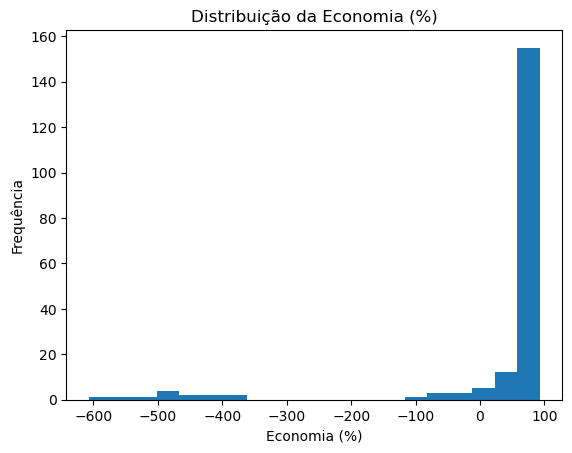

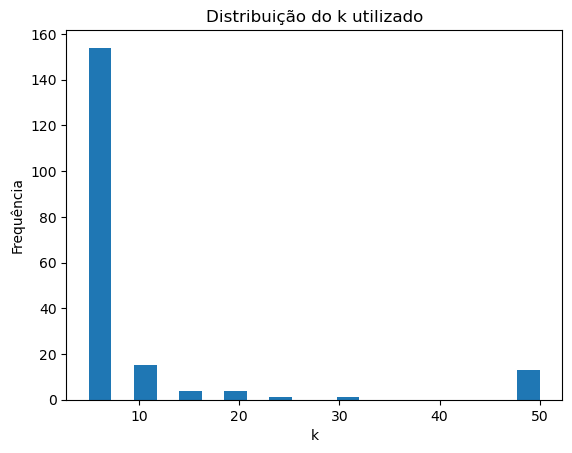

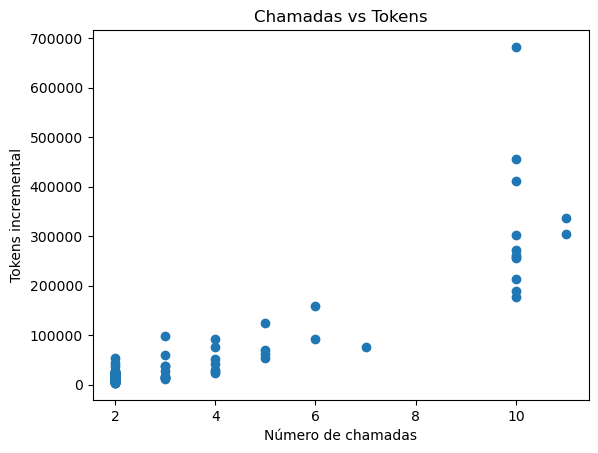

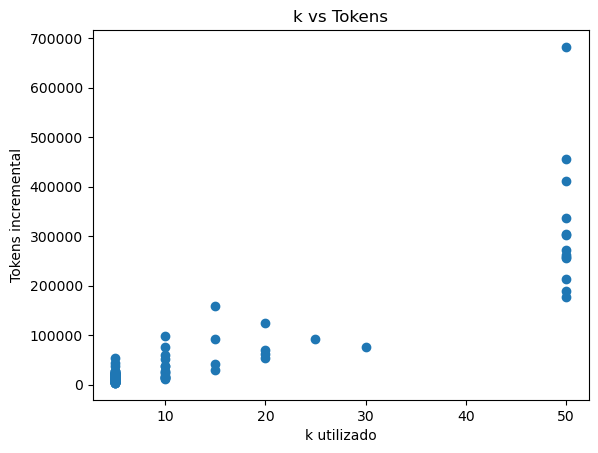

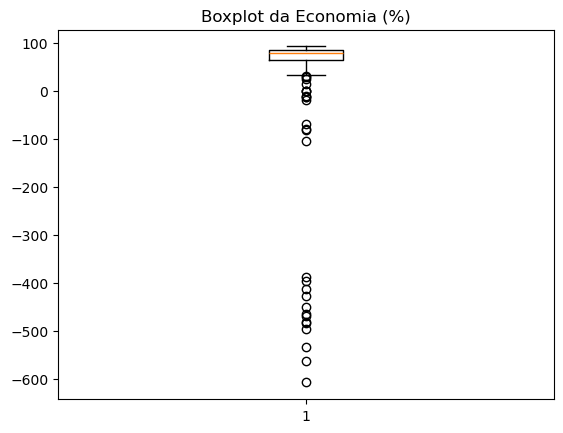


Arquivo 'resultados_analisados.csv' salvo com sucesso!


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. Carregar dados
# =========================
df = pd.read_csv("resultados_incremental_gemini_2_5.csv")

print("=== VISÃO GERAL ===")
print(df.head())
print("\nColunas:", df.columns)

# =========================
# 2. Economia de tokens
# =========================
df["economia_%"] = (1 - df["tokens_incremental"] / df["tokens_top50"]) * 100

print("\n=== ECONOMIA (%) ===")
print(df["economia_%"].describe())

# =========================
# 3. Estatísticas gerais
# =========================
print("\n=== TOKENS ===")
print("Incremental total:", df["tokens_incremental"].sum())
print("Top50 total:", df["tokens_top50"].sum())

economia_total = (1 - df["tokens_incremental"].sum() / df["tokens_top50"].sum()) * 100
print("Economia total (%):", economia_total)

# =========================
# 4. Distribuição de k
# =========================
print("\n=== K UTILIZADO ===")
print(df["k_utilizado"].describe())
print(df["k_utilizado"].value_counts())

# =========================
# 5. Número de chamadas
# =========================
print("\n=== CHAMADAS ===")
print(df["num_chamadas"].describe())

# =========================
# 6. Taxa de sucesso
# =========================
print("\n=== STATUS ===")
print(df["status"].value_counts(normalize=True))

# =========================
# 7. Correlação
# =========================
print("\n=== CORRELAÇÃO ===")
print(df[["k_utilizado", "tokens_incremental", "num_chamadas"]].corr())

# =========================
# 8. Análise por dificuldade
# =========================
facil = df[df["k_utilizado"] <= 10]
medio = df[(df["k_utilizado"] > 10) & (df["k_utilizado"] <= 30)]
dificil = df[df["k_utilizado"] > 30]

print("\n=== ANÁLISE POR DIFICULDADE ===")
print("Fácil - Economia média:", facil["economia_%"].mean())
print("Médio - Economia média:", medio["economia_%"].mean())
print("Difícil - Economia média:", dificil["economia_%"].mean())

# =========================
# 9. GRÁFICOS
# =========================

# Histograma da economia
plt.figure()
plt.hist(df["economia_%"], bins=20)
plt.title("Distribuição da Economia (%)")
plt.xlabel("Economia (%)")
plt.ylabel("Frequência")
plt.show()

# Histograma do k
plt.figure()
plt.hist(df["k_utilizado"], bins=20)
plt.title("Distribuição do k utilizado")
plt.xlabel("k")
plt.ylabel("Frequência")
plt.show()

# Scatter: chamadas vs tokens
plt.figure()
plt.scatter(df["num_chamadas"], df["tokens_incremental"])
plt.title("Chamadas vs Tokens")
plt.xlabel("Número de chamadas")
plt.ylabel("Tokens incremental")
plt.show()

# Scatter: k vs tokens
plt.figure()
plt.scatter(df["k_utilizado"], df["tokens_incremental"])
plt.title("k vs Tokens")
plt.xlabel("k utilizado")
plt.ylabel("Tokens incremental")
plt.show()

# Boxplot da economia
plt.figure()
plt.boxplot(df["economia_%"])
plt.title("Boxplot da Economia (%)")
plt.show()

# =========================
# 10. Salvar resultados analisados
# =========================
df.to_csv("resultados_analisados.csv", index=False)

print("\nArquivo 'resultados_analisados.csv' salvo com sucesso!")